In [1]:
import sys
sys.path.append('../')

import starry.utils.env

In [2]:
import os
import torch

from starry.utils.model_factory import loadModel
from starry.utils.config import Configuration


TRAINING_DIR = os.environ.get('TRAINING_DIR')

config = Configuration.createOrLoad(os.path.join(TRAINING_DIR, 'paraff/20241201-midiseq-paraff-se-ly+cc-d256-l8-dw0.02'))
model = loadModel(config['model'], postfix='JitEnc')

checkpoint = torch.load(config.localPath(config['best']), map_location='cpu')
model.load_state_dict(checkpoint['model'], strict=False)
model.eval()

/home/camus/work/deep-starry/env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2024-12-06 15:42:34.333367: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-12-06 15:42:34.333406: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-12-06 15:42:34.334590: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-12-06 15:42:34.341479: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow b

SeqShareSEJitEnc(
  (word_emb): Embedding(324, 256, padding_idx=0)
  (word_prj): Linear(in_features=256, out_features=324, bias=False)
  (latent_prj): Linear(in_features=256, out_features=256, bias=False)
  (latent_emb): Linear(in_features=256, out_features=256, bias=True)
  (position_enc): PositionalEncoding()
  (layer_norm): LayerNorm((256,), eps=1e-06, elementwise_affine=True)
  (attention): AttentionStack(
    (layer_stack): ModuleList(
      (0-7): 8 x EncoderLayer(
        (slf_attn): MultiHeadAttention(
          (w_qs): Linear(in_features=256, out_features=256, bias=False)
          (w_ks): Linear(in_features=256, out_features=256, bias=False)
          (w_vs): Linear(in_features=256, out_features=256, bias=False)
          (fc): Linear(in_features=256, out_features=256, bias=False)
          (attention): ScaledDotProductAttention(
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (dropout): Dropout(p=0.1, inplace=False)
          (layer_norm): LayerNor

In [3]:
import yaml
import os


scores = yaml.safe_load(open(os.path.expanduser('~/data/maestro-v3.0.0/2004/midiseq.yaml'), 'r'))
scores

{'MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_05_Track05_wav.midi': ['Sustain95 Soft127 Sustain127 Sustain127 Soft127 Sustain127 Shift1000 Shift90 Vel63 On71 Soft127 Soft127 Shift100 Off71 Sustain95 Sustain95 Sustain63 Shift90 Vel47 On55 Shift10 Vel55 On71 Sustain63 Soft95 Sustain63 Sustain63 Soft95 Sustain63 Sustain95 Sustain95 Sustain127 Sustain127 Shift180 On59 Sustain127 Soft95 Shift30 Off55 Soft95 Shift130 Off59 On62 Soft95 Shift120 Off62 Shift30 Vel79 On72 Shift10 Off71 Shift10 Vel59 On67 Shift30 Off72 Shift160 Vel63 On57 Vel71 On74 Sustain95 Shift20 Off67',
  'Sustain63 Sustain0 Shift40 Vel79 On72 Shift60 Off74 Vel51 On74 Shift10 Off72 Shift40 Vel63 On72 Shift20 Vel59 On67 Shift10 Off74 Shift100 Off67 Shift50 On66 Shift180 Off66 Shift10 Off72 Off57 Vel71 On71 Shift40 Vel35 On64 Shift30 Off71 Vel47 On72 Shift80 Off72 Shift10 Vel71 On74 Shift30 Vel51 On59 Shift50 Off64 Shift120 Vel63 On62 Shift190 On66 Shift30 Off62 Shift140 Vel59 On67 Shift20 Off66 Sustain31 

In [4]:
from tqdm import tqdm

from starry.paraff.midiseq import T2I


sum_lib = {}
for name, score in tqdm(scores.items()):
	seqs = [[T2I[token] for token in seg.strip().split(' ')] for seg in score]
	summaries = []

	with torch.no_grad():
		for ids in seqs:
			input = torch.tensor([2] + ids[:510] + [3]).long()[None]
			summaries.append(model(input))

	sum_lib[name] = torch.cat(summaries, dim=0)

sum_lib

100%|██████████| 132/132 [00:17<00:00,  7.39it/s]


{'MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_05_Track05_wav.midi': tensor([[-1.1383, -0.3965, -0.9811,  ..., -0.0335, -0.6318,  0.3925],
         [-1.3986,  0.9145, -0.5093,  ..., -1.2011, -0.9516,  0.2796],
         [-0.7696,  0.4149, -0.8300,  ...,  0.1613, -0.3015, -0.8165],
         ...,
         [-0.0908, -0.0503, -1.2912,  ..., -1.7248, -0.8371, -1.4649],
         [-1.1531, -0.4442, -0.9622,  ..., -1.1344,  0.1820, -0.3535],
         [-0.4976, -0.8329, -0.4178,  ..., -0.3601,  1.6981,  0.0826]]),
 'MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_06_Track06_wav.midi': tensor([[-0.5816,  0.5019, -1.0654,  ..., -0.5663, -1.5806,  0.8540],
         [-0.3982,  0.7911, -0.3036,  ..., -1.3152, -0.6868, -0.3021],
         [-0.9400,  0.0711, -0.6221,  ..., -0.9886,  0.5243,  0.1148],
         ...,
         [-0.9952, -0.9468,  0.0884,  ...,  0.2417,  0.0721, -0.8520],
         [-0.3781, -0.0421, -0.1226,  ..., -0.2064, -1.3551,  0.8598],
         [-2.

In [5]:
next(iter(sum_lib.values())).shape

torch.Size([16, 256])

In [6]:
torch.save(sum_lib, os.path.expanduser('~/data/maestro-v3.0.0/2004/midiseq-sum.pt'))

---
## library inner matching

In [7]:
sum_arr = torch.stack(tuple(sum_lib.values()), dim=0)
sum_arr.shape

torch.Size([132, 16, 256])

In [8]:
sum4 = sum_arr[:, :4].sum(dim=1)
sum4.shape

torch.Size([132, 256])

In [9]:
sum4_norm = sum4 / sum4.norm(dim=-1)[:, None]
sum4_norm.shape

torch.Size([132, 256])

In [10]:
lib_match = torch.matmul(sum4_norm, sum4_norm.transpose(0, 1))
lib_match.shape

torch.Size([132, 132])

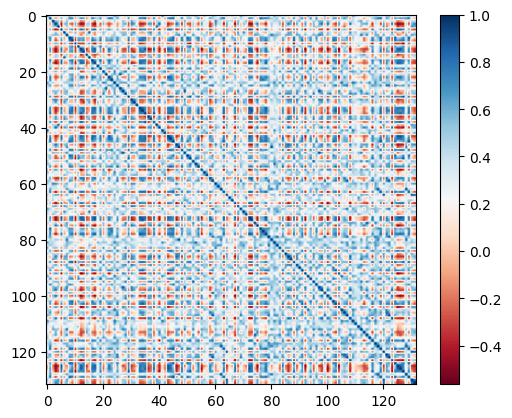

In [11]:
from matplotlib import pyplot as plt
import matplotlib


%matplotlib inline


plt.imshow(lib_match, cmap='RdBu')
plt.colorbar()
plt.show()